# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Riana Shofiatul Khoeriyah
- Email: rianashofiatulkhoeriyah24@gmail.com
- Id Dicoding: riana_sk

## Persiapan

### Menyiapkan library yang dibutuhkan

Pada bagian ini dipergunakan untuk menginstall dan mengimport seluruh library yang dibutuhkan dalam pengerjaan proyek akhir ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import math

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import chi2_contingency
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('/content/drive/MyDrive/proyek_pertama_penerapan_data_science/employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Data dalam file employee_data.csv ini berisi rincian demografi atau metrik yang berkaitan dengan pekerjaan dan status pengunduran diri (attrition).
  - EmployeeId - ID unik setiap karyawan      
  - Age - Umur karyawan (tahun)     
  - Attrition - Status pengunduran diri karyawan (Yes = Keluar, No = Tetap bekerja)                 
  - BusinessTravel - Frekuensi perjalanan dinas (Non-Travel, Travel_Rarely, Travel_Frequently)       
  - DailyRate - Pendapatan atau tarif harian karyawan          
  - Department - Departemen tempat karyawan bekerja (Sales, RnD, Human Resources)      
  - DistanceFromHome - Jarak rumah ke tempat kerja         
  - Education - Tingkat pendidikan karyawan (SMA, S1, S2, dan lainnya)                 
  - EducationField - Pidang pendidikan (Science, Economy, Psycology, Engineering, dll)
  - EmployeeCount - Jumlah karyawan
  - EnvironmentSatisfaction - Tingkat kepuasan terhadap lingkungan kerja
  - Gender - Jenis kelamin karyawan     
  - HourlyRate - Pendapatan atau tarif per jam          
  - JobInvolvement - Tingkat keterlibatan dalam pekerjaan       
  - JobLevel - Tingkat jabatan karyawan          
  - JobRole - Posisi atau jabatan                  
  - JobSatisfaction - Tingkat kepuasan terhadap pekerjaan
  - MaritalStatus - Status pernikahan (Single, Married, Divorced)
  - MonthlyIncome - Pendapatan bulanan            
  - MonthlyRate - Tarif atau nilai bulanan (Bukan gaji bulanan)        
  - NumCompaniesWorked - Jumlah perusahaan tempat karyawan pernah bekerja sebelumnya.
  - Over18 - Apakah karyawan berusia diatas 18 tahun.                
  - OverTime - Apakah karyawan sering lembur              
  - PercentSalaryHike - Persentase kenaikan gaji terakhir       
  - PerformanceRating - Nilai performa karyawan      
  - RelationshipSatisfaction - Tingkat kepuasan hubungan kerja dengan atasan atay rekan kerja
  - StandardHours - Jam kerja standar
  - StockOptionLevel - tingkat kepemilikan saham perusahaan
  - TotalWorkingYears - Total pengalaman kerja
  - TrainingTimesLastYear - Jumlah pelatihan yang diikuti selama 1 tahun terakhir
  - WorkLifeBalance - Tingkat keseimbangan kerja dan kehidupan pribadi
  - YearsAtCompany - Lama bekerja di perusahaan saat ini (tahun)
  - YearsInCurrentRole - Lama berada pada posisi/jabatan saat ini
  - YearsSinceLastPromotion - Lama sejak promosi terakhir (tahun)
  - YearsWithCurrManager - Lama bekerja dengan manager saat ini (tahun)

##Cek Nilai Unik untuk Setiap Variabel Kategorik

In [4]:
for feature in df.select_dtypes(include='object'):
  print(feature)
  print(df[feature].unique(), '\n')

BusinessTravel
['Travel_Frequently' 'Travel_Rarely' 'Non-Travel'] 

Department
['Human Resources' 'Research & Development' 'Sales'] 

EducationField
['Other' 'Medical' 'Life Sciences' 'Marketing' 'Technical Degree'
 'Human Resources'] 

Gender
['Male' 'Female'] 

JobRole
['Human Resources' 'Healthcare Representative' 'Research Scientist'
 'Sales Executive' 'Manager' 'Laboratory Technician' 'Research Director'
 'Manufacturing Director' 'Sales Representative'] 

MaritalStatus
['Married' 'Single' 'Divorced'] 

Over18
['Y'] 

OverTime
['Yes' 'No'] 



##Melihat Statistik Deskriptif untuk seluruh variabel

In [5]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.describe(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1043,961,606,882,326,673,1470,1054


Berdasarkan analisis statistik deskriptif yang telah dilakukan, semua karyawan berusia di atas 18 tahun, hal ini dilihat dari fitur `Over18` yang memiliki 1 data, yaitu Y. Selain itu, fitur `EmployeeCount` juga memiliki 1 nilai unik. Oleh karena itu, kita dapat mengeliminasi kedua fitur ini karena tidak memiliki pengaruh besar terhadap masalah bisnis.

In [7]:
df = df.drop(['Over18', 'EmployeeCount'], axis=1, errors='ignore')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,4,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,3,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,3,...,2,80,3,20,2,3,5,3,0,2


## Data Preparation / Preprocessing

##Penanganan Missing Value dan Duplikat

In [8]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0


Dalam penanganan missing value dan duplikat ini, dataset memiliki beberapa nilai yang hilang dalam fitur `Attrition`. Fitur `Attrition` ini merupakan fitur utama dalam masalah bisnis yang akan diselesaikan, kita perlu menghapus data dengan nilai yang hilang tersebut.

In [9]:
df.dropna(inplace=True)
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0


Selanjutnya kita lakukan pengecekan duplikasi data

In [10]:
df.duplicated().sum()

np.int64(0)

Hasilnya, tidak ada data yang duplikat

##Exploratory Data Analysis (EDA)

##Decoding Variabel Kategorik

Decoding Ordinal untuk fitur-fitur berikut:
- Education
  - 1: Below College
  - 2: College
  - 3: Bachelor
  - 4: Master
  - 5: Doctor
- EnvironmentSatisfaction
  - 1: Low
  - 2: Medium
  - 3: High
  - 4: Very High
- JobInvolvement
  - 1: Low
  - 2: Medium
  - 3: High
  - 4: Very High
- JobSatisfaction
  - 1: Low
  - 2: Medium
  - 3: High
  - 4: Very High
- PerformanceRating
  - 1: Low
  - 2: Good
  - 3: Excellent
  - 4: Outstanding
- RelationshipSatisfaction
  - 1: Low
  - 2: Medium
  - 3: High
  - 4: Very High
- WorkLifeBalance
  - 1: Low
  - 2: Good
  - 3: Excellent
  - 4: Outstanding

In [11]:
def ordinal_decoding(df, features_to_decode):
    """
    Convert encoded feature(s) in a DataFrame to corresponding categorical labels

    Parameters
        df (pandas.DataFrame) : The DataFrame with feature(s) to be converted
        features_to_decode (str or list of str) : The feature name(s) to convert

    Returns
        pandas.DataFrame : The DataFrame with feature(s) as categorical labels
    """
    # Ensure features_to_decode is always a list for consistent iteration
    if isinstance(features_to_decode, str):
        features_to_decode = [features_to_decode]

    for feature_name in features_to_decode:
        category_map = {} # Initialize for each feature_name to prevent UnboundLocalError

        if feature_name == 'Attrition':
            category_map = {0: 'No', 1: 'Yes'}
        elif feature_name == 'Education':
            category_map = {1: 'Below College', 2: 'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
        elif feature_name in ['WorkLifeBalance', 'PerformanceRating']:
            category_map = {1: 'Low', 2: 'Good', 3:'Excellent', 4:'Outstanding'}
        elif feature_name in ['EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'RelationshipSatisfaction']:
            category_map = {1: 'Low', 2: 'Medium', 3:'High', 4:'Very High'}

        if category_map: # Only apply mapping if a category_map was found for the feature_name
            df[feature_name] = df[feature_name].map(category_map)
        else:
            print(f"Warning: No specific ordinal mapping defined for feature '{feature_name}'. Skipping decoding for this feature.")

    return df

In [12]:
df = ordinal_decoding(df, 'Attrition')
df = ordinal_decoding(df, 'Education')
df = ordinal_decoding(df, ['EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'RelationshipSatisfaction'])
df = ordinal_decoding(df, ['PerformanceRating', 'WorkLifeBalance'])

df.head()


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,Yes,Travel_Rarely,1141,Research & Development,11,College,Medical,Low,...,Low,80,0,15,2,Low,1,0,0,0
2,3,51,Yes,Travel_Rarely,1323,Research & Development,4,Master,Life Sciences,Low,...,High,80,3,18,2,Outstanding,10,0,2,7
3,4,42,No,Travel_Frequently,555,Sales,26,Bachelor,Marketing,High,...,Very High,80,1,23,2,Outstanding,20,4,4,8
6,7,40,No,Travel_Rarely,1124,Sales,1,College,Medical,Medium,...,High,80,3,6,2,Good,4,3,0,2
7,8,55,Yes,Travel_Rarely,725,Research & Development,2,Bachelor,Medical,Very High,...,Very High,80,1,24,2,Excellent,5,2,1,4


Melihat statistik deskriptif untuk semua variabel

In [13]:
df.describe(include='all')

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1058.000000,1058.000000,1058,1058,1058.000000,1058,1058.000000,1058,1058,1058,...,1058,1058.0,1058.000000,1058.000000,1058.000000,1058,1058.000000,1058.00000,1058.000000,1058.000000
unique,NaN,NaN,2,3,NaN,3,NaN,5,6,4,...,4,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN
top,NaN,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,Bachelor,Life Sciences,High,...,High,NaN,NaN,NaN,NaN,Excellent,NaN,NaN,NaN,NaN
freq,NaN,NaN,879,746,NaN,701,NaN,410,436,335,...,324,NaN,NaN,NaN,NaN,638,NaN,NaN,NaN,NaN
mean,736.656900,37.055766,NaN,NaN,809.542533,NaN,8.978261,NaN,NaN,NaN,...,NaN,80.0,0.762760,11.435728,2.769376,NaN,7.065217,4.26087,2.203214,4.142722
std,427.440538,9.410421,NaN,NaN,408.478049,NaN,8.040608,NaN,NaN,NaN,...,NaN,0.0,0.837537,8.016429,1.302689,NaN,6.265227,3.61747,3.266948,3.599044
min,2.000000,18.000000,NaN,NaN,102.000000,NaN,1.000000,NaN,NaN,NaN,...,NaN,80.0,0.000000,0.000000,0.000000,NaN,0.000000,0.00000,0.000000,0.000000
25%,364.250000,30.000000,NaN,NaN,465.250000,NaN,2.000000,NaN,NaN,NaN,...,NaN,80.0,0.000000,6.000000,2.000000,NaN,3.000000,2.00000,0.000000,2.000000
50%,731.500000,36.000000,NaN,NaN,817.500000,NaN,7.000000,NaN,NaN,NaN,...,NaN,80.0,1.000000,10.000000,3.000000,NaN,5.000000,3.00000,1.000000,3.000000
75%,1117.750000,43.000000,NaN,NaN,1168.500000,NaN,13.000000,NaN,NaN,NaN,...,NaN,80.0,1.000000,16.000000,3.000000,NaN,9.000000,7.00000,3.000000,7.000000


##Analisis Distribusi Kelas Target

In [14]:
# Distribusi variabel target (Attrition)
attrition_counts = df['Attrition'].value_counts()
attrition_counts

,count
Attrition,
No,879
Yes,179


In [15]:
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100
attrition_percentage

,proportion
Attrition,
No,83.081285
Yes,16.918715


#Distribusi Target (Attrition)

Pada analisis distribusi kelas target attrition, dimana pada kelas target ini memberikan informasi terkait status pengunduran diri karyawan, di dapat beberapa insight sebagai berikut:
- No (Karyawan tetap bekerja): 83.08%
- Yes (Keluar): 16.91%
Hasil dari analisis ini menunjukkan bahwa sebanyak 83.08% atau setara dengan 879 karyawan tetap bekerja, sedangkan `Attrition` tetap signifikan pada angka 16.91% atau setara dengan 179 karyawan yang keluar.

##Analisis Fitur Numerik

In [16]:
numerical, categorical = [], []

for feature in df.columns:
  if not df[feature].dtype == 'object':
    numerical.append(feature)
  else:
    categorical.append(feature)

In [17]:
numerical_description = df[numerical].describe()
numerical_description

,EmployeeId,Age,DailyRate,DistanceFromHome,HourlyRate,JobLevel,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.0,1058.000000,1058.000000,1058.000000,1058.000000,1058.00000,1058.000000,1058.000000
mean,736.656900,37.055766,809.542533,8.978261,65.643667,2.090737,6625.945180,14267.281664,2.706994,15.155955,80.0,0.762760,11.435728,2.769376,7.065217,4.26087,2.203214,4.142722
std,427.440538,9.410421,408.478049,8.040608,20.324861,1.136514,4837.695042,7048.077305,2.523526,3.641097,0.0,0.837537,8.016429,1.302689,6.265227,3.61747,3.266948,3.599044
min,2.000000,18.000000,102.000000,1.000000,30.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,364.250000,30.000000,465.250000,2.000000,48.000000,1.000000,2900.250000,8277.250000,1.000000,12.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.00000,0.000000,2.000000
50%,731.500000,36.000000,817.500000,7.000000,65.000000,2.000000,4903.500000,14201.000000,2.000000,14.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.00000,1.000000,3.000000
75%,1117.750000,43.000000,1168.500000,13.000000,83.000000,3.000000,8736.500000,20364.000000,4.000000,18.000000,80.0,1.000000,16.000000,3.000000,9.000000,7.00000,3.000000,7.000000
max,1470.000000,60.000000,1499.000000,29.000000,100.000000,5.000000,19999.000000,26999.000000,9.000000,25.000000,80.0,3.000000,40.000000,6.000000,40.000000,18.00000,15.000000,17.000000


#Deskripsi Kolom Numerik

- `Age`: Rata-rata karyawan berusia 37 tahun.
- `MonthlyIncome`: Rata-rata pendapatan karyawan sebanyak 6,6 juta.
- DistanceFromHome: Sebagian besar karyawan tinggal dekat dengan kantor yang berjarak rata-rata 8,9 km.
- YearsAtCompany: Sebagian besar karyawan bekerja di perusahaan selama 5 - 9 tahun.

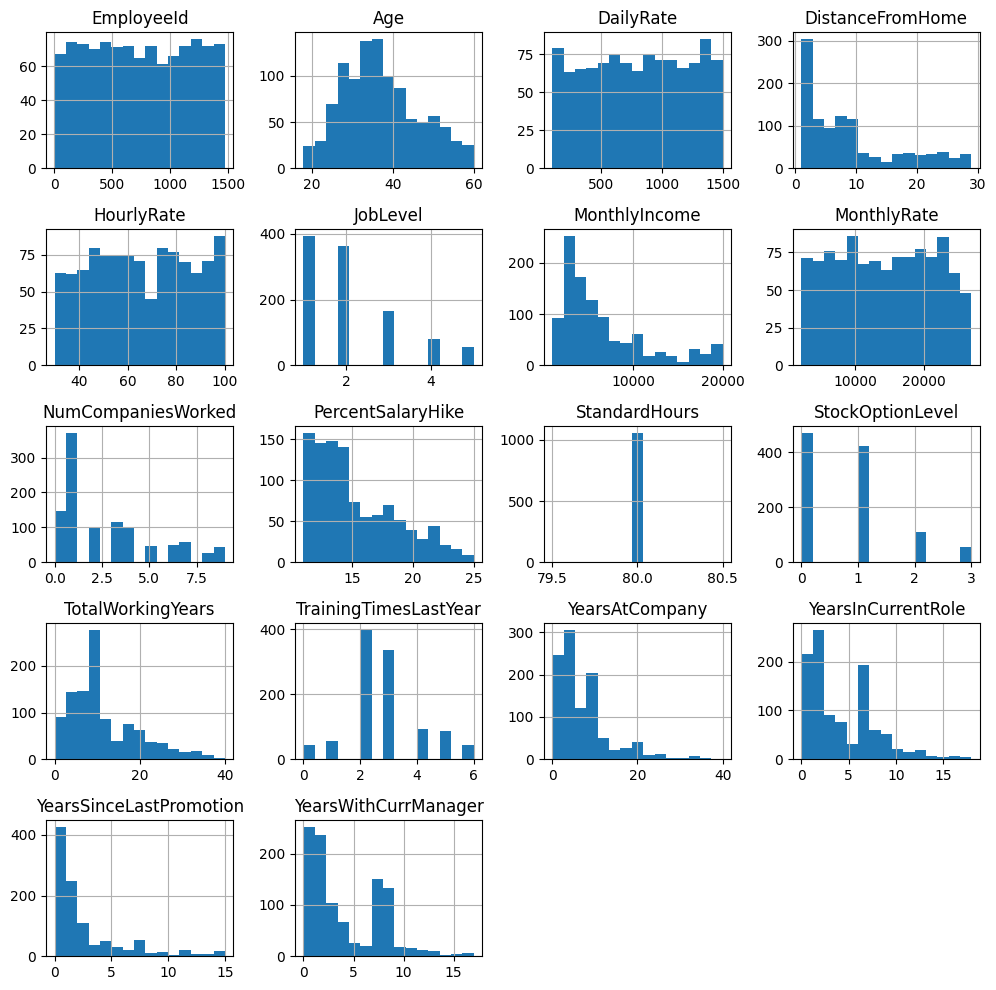

In [18]:
df[numerical].hist(bins=15, figsize=(10, 10))
plt.tight_layout()
plt.show()

Berdasarkan grafik histogram diatas, sebagian besar fitur numerik menunjukkan distribusi yang condong ke arah kanan (right-skewed). Fitur-fitur yang termasuk ke dalam right-skewed diantaranya `DistanceFromHome`, `MonthlyIncome`, `NumCompaniesWorked`, `PercentSalaryHike`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `JobLevel`, `StockOptionLevel`, dan `YearsWithCurrManager`. Hal ini mengindikasikan bahwa sebagian besar nilai berada pada kisaran rendah, sementara hanya sedikit yang memiliki nilai tinggi. Sementara itu, fitur `Age` dan `TrainingTimesLastYear` memiliki distribusi yang lebih simetris atau mendekatii normal, mencerminkansebaran nilai yang relatif seimbang di rat-rata. Kemudian, beberapa fitur lain seperti `EmployeeId`, `DailyRate`, `HourlyRate`, dan `MonthlyRate` memiliki sebaran yang merata tanpa pola distribusi khusus. Selain itu, terdapat fitur seperti `EmployeeCount` dan `StandartHours` tidak memiliki variasi sebaran sama sekali, sehinggga kemungkinan tidak memiliki kontribusi informasi dalam proses pemodelan selanjutnya.

##Analisis Hubungan Fitur Numerik terhadap Target

Dengan menggunakan visualisasi, kita dapat meihat hubungan fitur numerik terhadap `Attrition`

/tmp/ipykernel_468/2555483119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')


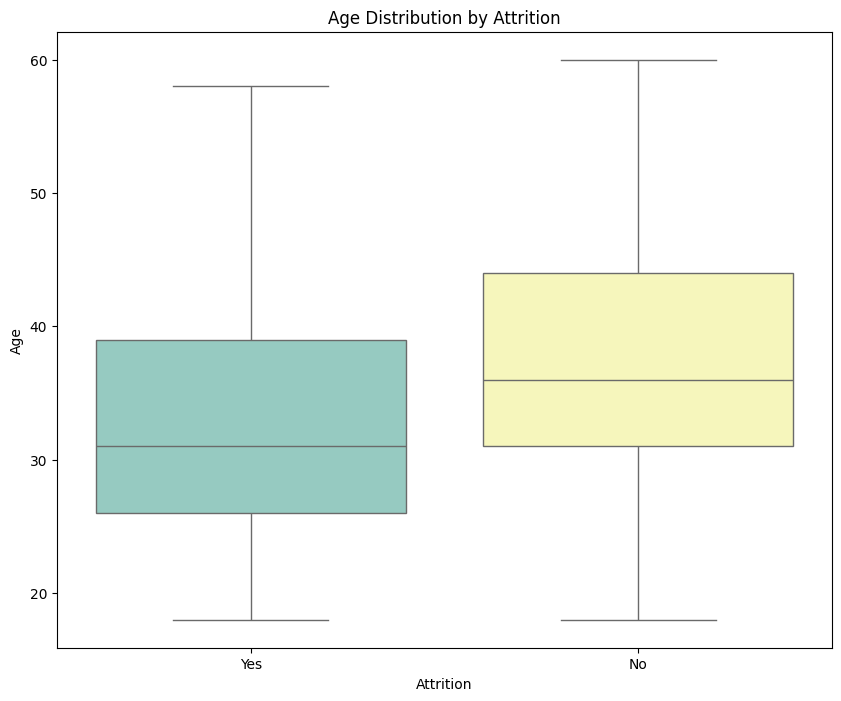

In [19]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')
plt.title('Age Distribution by Attrition')
plt.show()

/tmp/ipykernel_468/2089516853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')


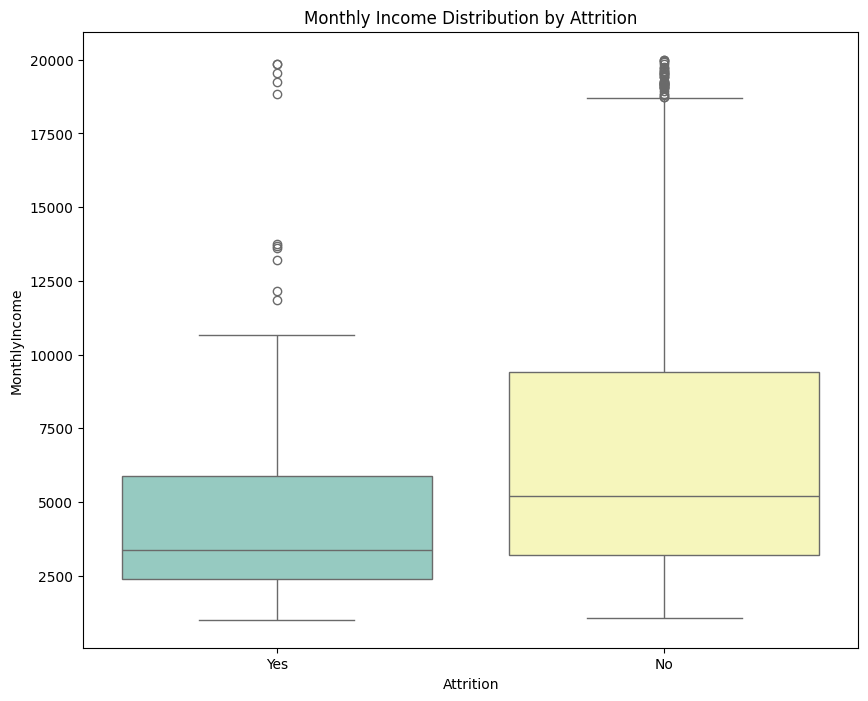

In [20]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income Distribution by Attrition')
plt.show()

/tmp/ipykernel_468/2084903159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette='Set3')


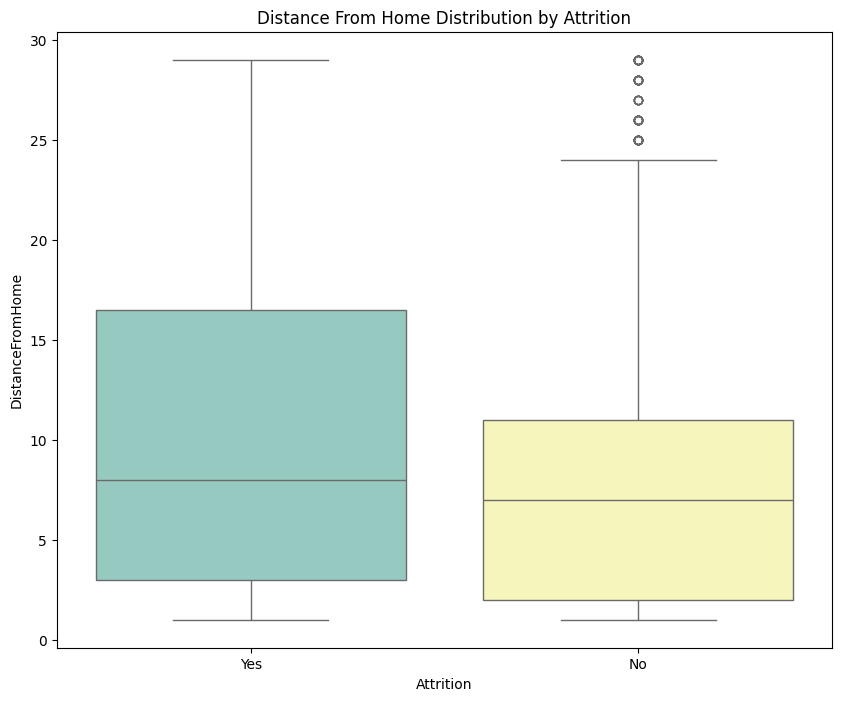

In [21]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette='Set3')
plt.title('Distance From Home Distribution by Attrition')
plt.show()

##Hasil Analisis Fitur Numerik
- `Age`: Karyawan dengan `Attrition` pada rentang umur 30 - 45 tahun cenderung lebih memilih tetap bekerja, dibandingkan dengan karyawan dengan rentang usia 25 - 38 tahun.
- `MonthlyIncome`: Karyawan dengan `Attrition` memiliki distribusi pendaptan yang lebih rendah dibandingkan dengan karyawan yang memilih tetap bekerja.
- `DistanceFromHome`: Tidak ada perbedaan yang signifikan dalam jarak kantor dari rumah karyawan yang keluar dengan yang tetap bekerja.

##Distribusi YearsAtCompany dan TotalWorkingYears

Menganalisis distribusi fitur `YearsAtCompany` dan `TotalWorkingYear` karena fitur ini relevan dalam memengaruhi `Attrition`.

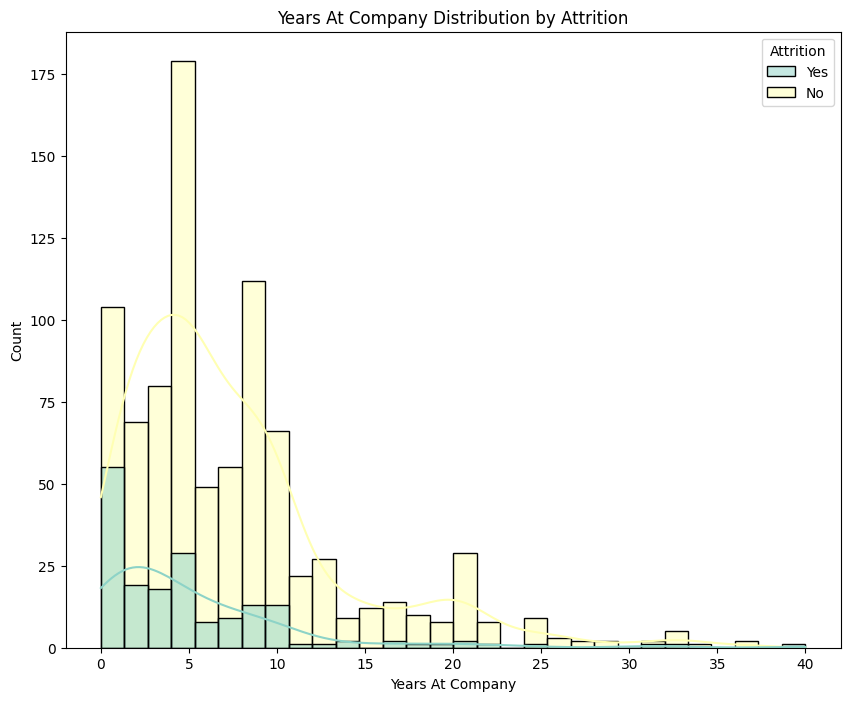

In [22]:
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', kde=True, palette='Set3', bins=30)
plt.title('Years At Company Distribution by Attrition')
plt.xlabel('Years At Company')
plt.ylabel('Count')
plt.show()

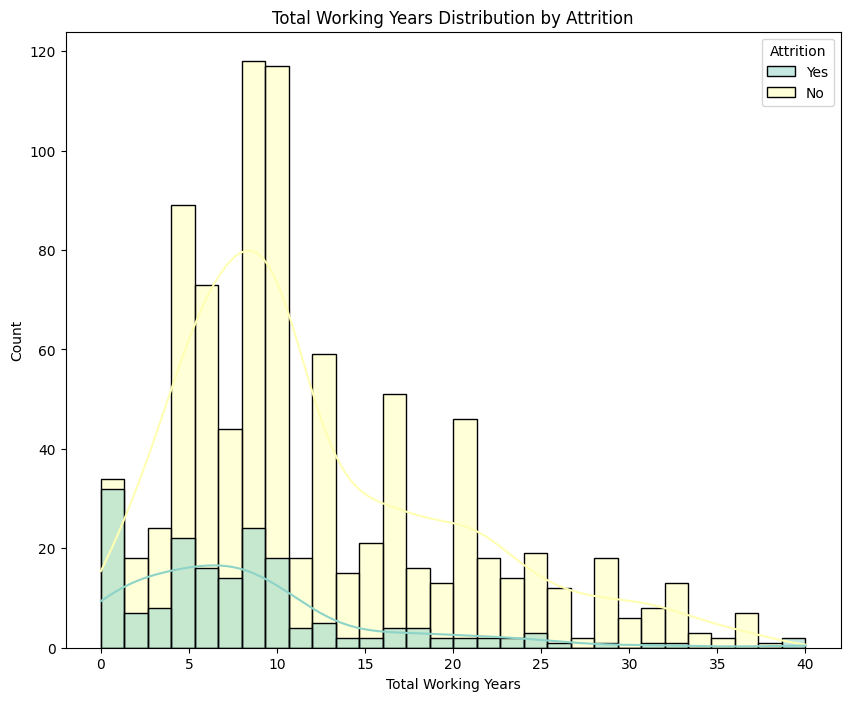

In [23]:
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='TotalWorkingYears', hue='Attrition', kde=True, palette='Set3', bins=30)
plt.title('Total Working Years Distribution by Attrition')
plt.xlabel('Total Working Years')
plt.ylabel('Count')
plt.show()

Berdasarkan distribusi fitur `YearsAtCompany` dan `TotalWorkingYears` terhadap `Attrition`:
1. `YearsAtCompany`
  -  Karyawan dengan masa kerja singkat yakni sekitar 0 - 5 tahun masa kerja, memiliki risiko `Attrition` lebih tinggi.
  - Distribusi menunjukkan bahwa karyawan baru memiliki kecenderungan untuk lebih cepat.
2. `TotalWorkingYears`
  - Karyawan dengan pengalaman kerja kebih sedikit yakni sekitar 0 - 10 tahun kebih sering keluar dibandingkan yang memiliki pengalaman kerj alebih panjang.
  - Hal ini menunjukkan pentingknya retensi awal karir dan pengalaman karyawan.

##Analisis Interaksi Antar Fitur

Bagian ini digunakan untuk melihat hubungan antara dua fitur utama dan bagaimana keduanya berinteraksi dengan target `Attrition`.

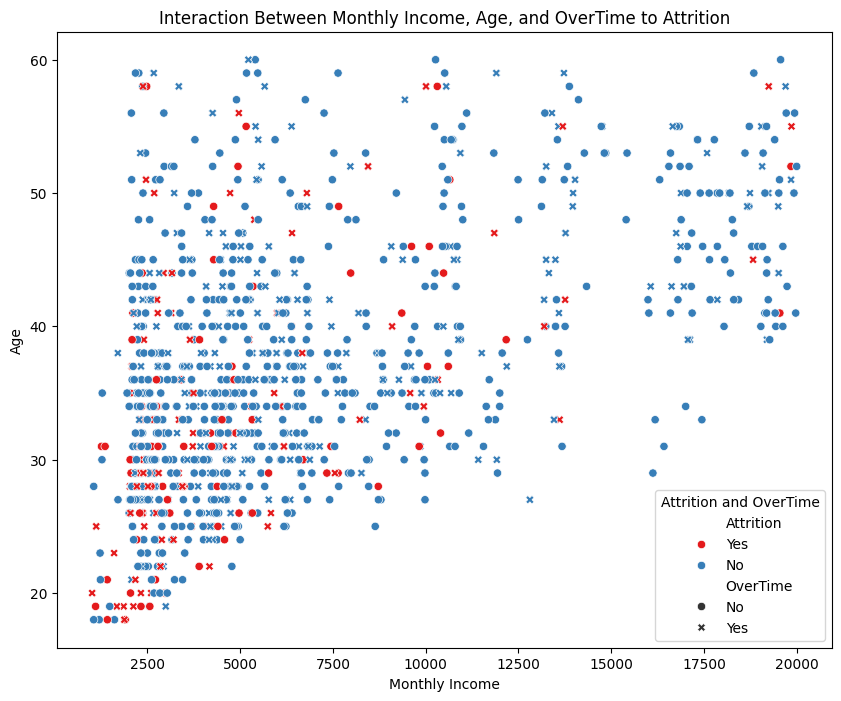

In [24]:
plt. figure(figsize=(10, 8))
sns.scatterplot(data=df, x='MonthlyIncome', y='Age', hue='Attrition', style='OverTime', palette='Set1')
plt.title('Interaction Between Monthly Income, Age, and OverTime to Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Age')
plt.legend(title='Attrition and OverTime')
plt.show()

Grafik di atas menunjukkan hubungna antar fitur `MonthlyIncome`, `Age`, dan `Overtime` dengan `Attrition`.
1. `Attrition` dan `Overtime`
  - Karyawan yang sering lembur yang ditandai dengan * cenderung lebih sering mengalami attrition yang ditandai dengan warna merah dibandingkan dengan yang tidak lembur.
2. `Attrition` dan `MonthlyIncome`
  - Karyawan dengan pendapatan bulanan yang lebih rendah memiliki tingkat attrition lebih tinggi dibandingkan dengan karyawan yang berpendaptan lebih tinggi.
  - Hal ini terlihat dari kepadatan titik merah yang lebih banyak di sisi koro grafik (pendapatan bulanan rendah).
3. `Attrition` dan `Age`
  - Karyawan yang lebih muda cenderung mengalami attrition lebih sering, terlihat daru konsentrasi titik biru di bagian bawah grafik (usia rendah).
4. Interaksi antara Ketiga Variabel
  - Karyawan yang muda, berpendapatan rendah, dan sering lembur memiliki kecenderungan attrition yang lebih tinggi.

##Hubungan Fitur Kategorik terhadap Target


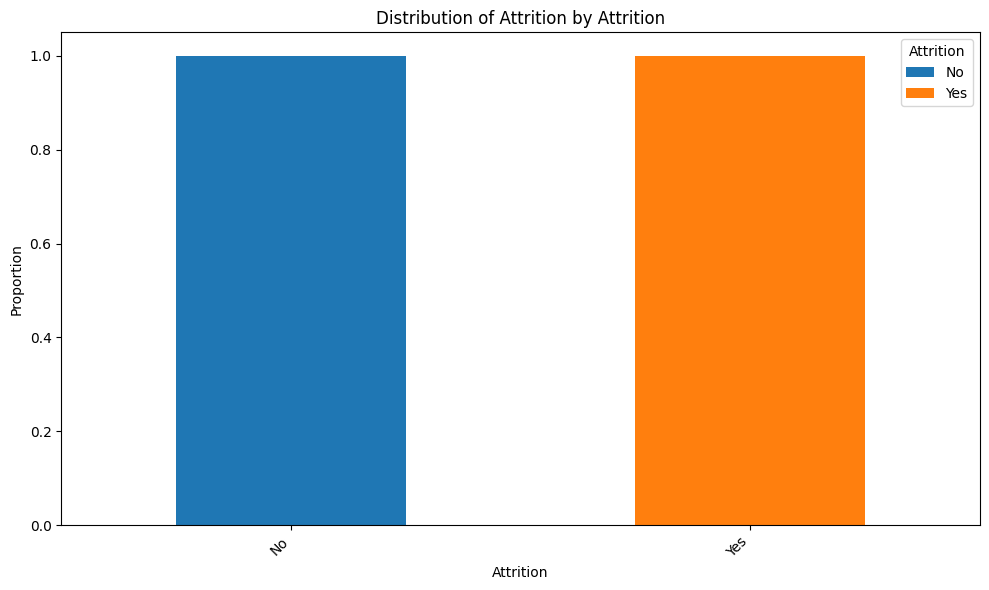

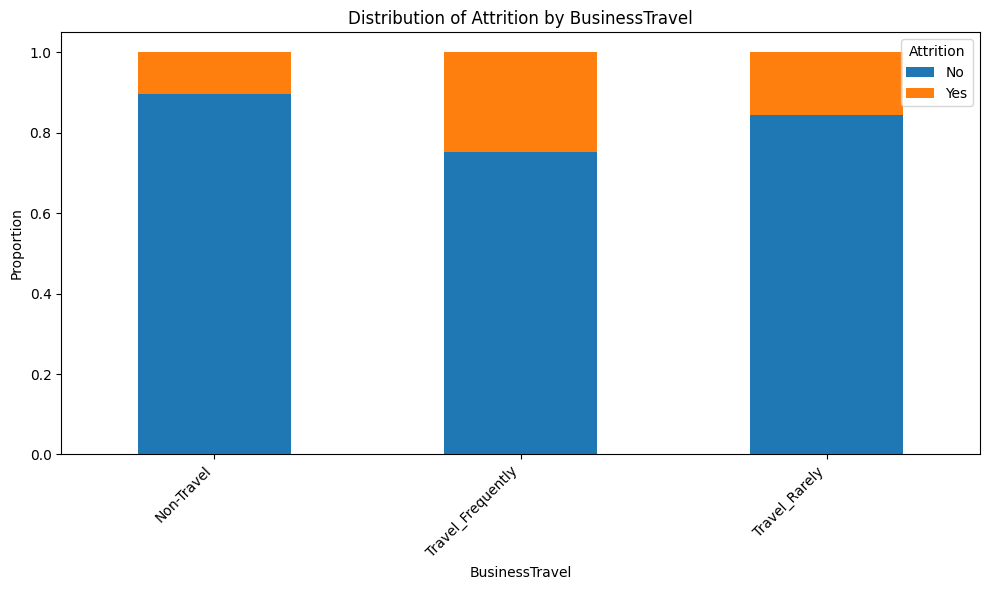

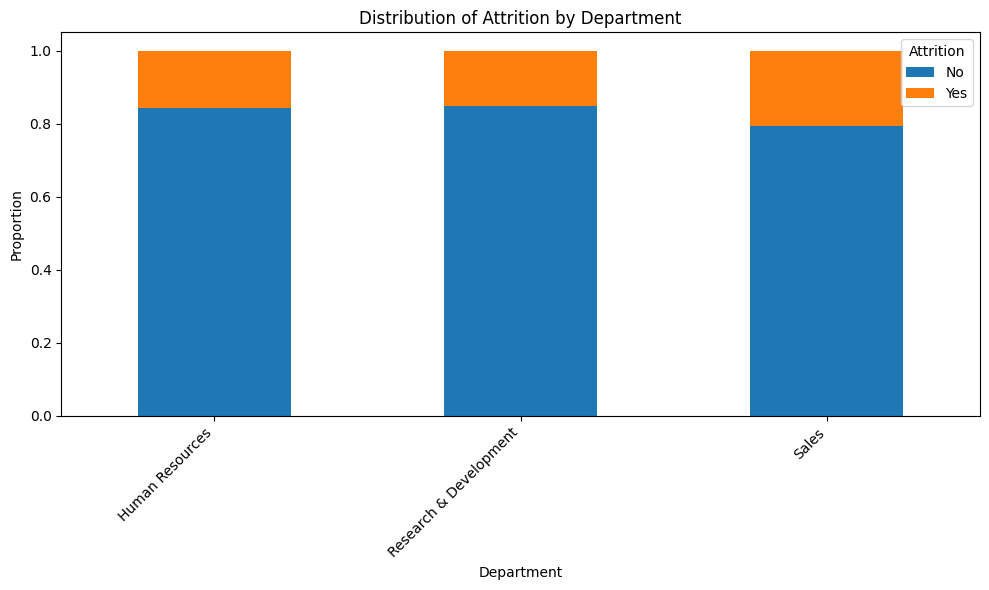

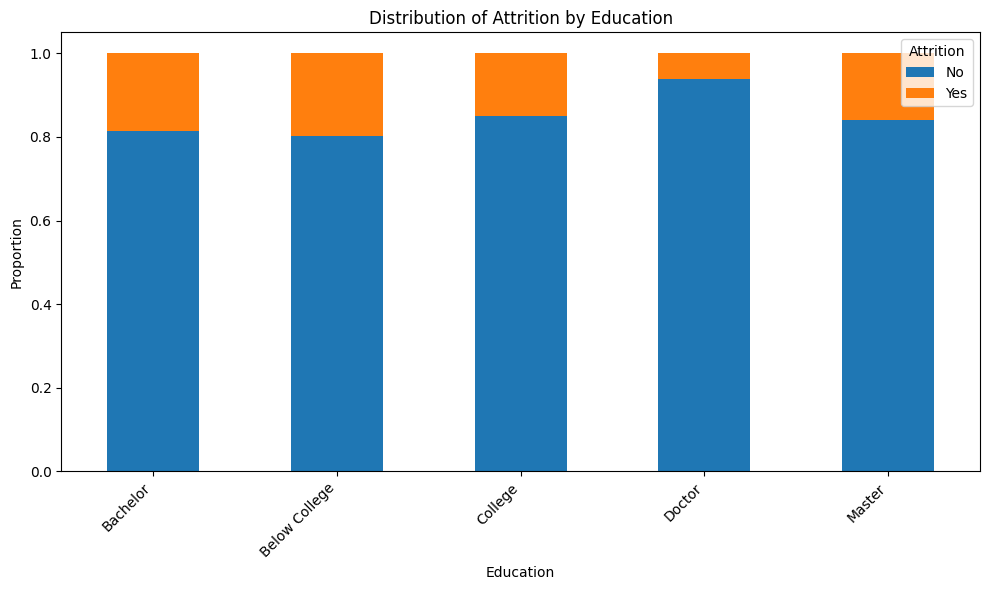

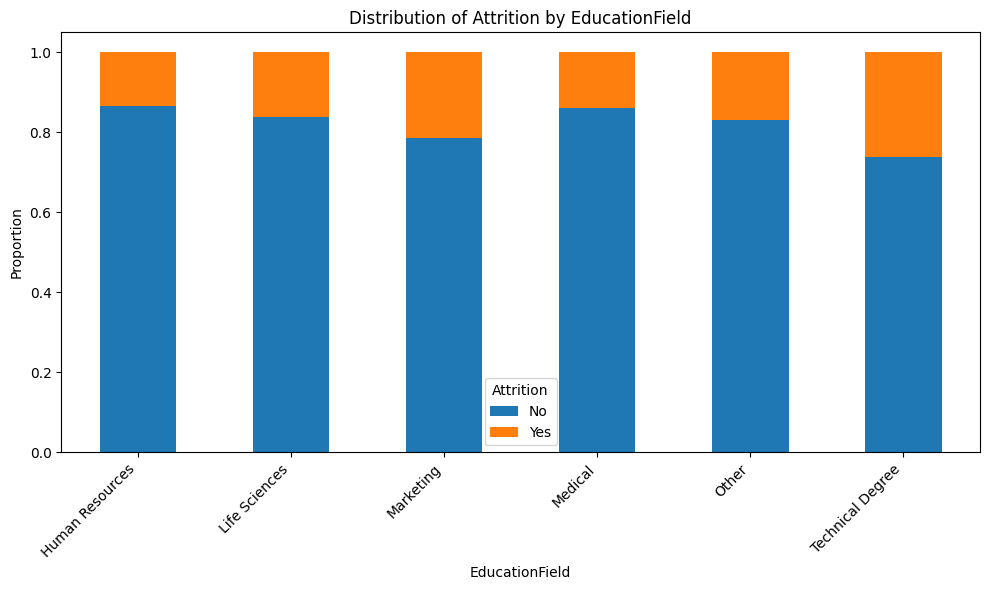

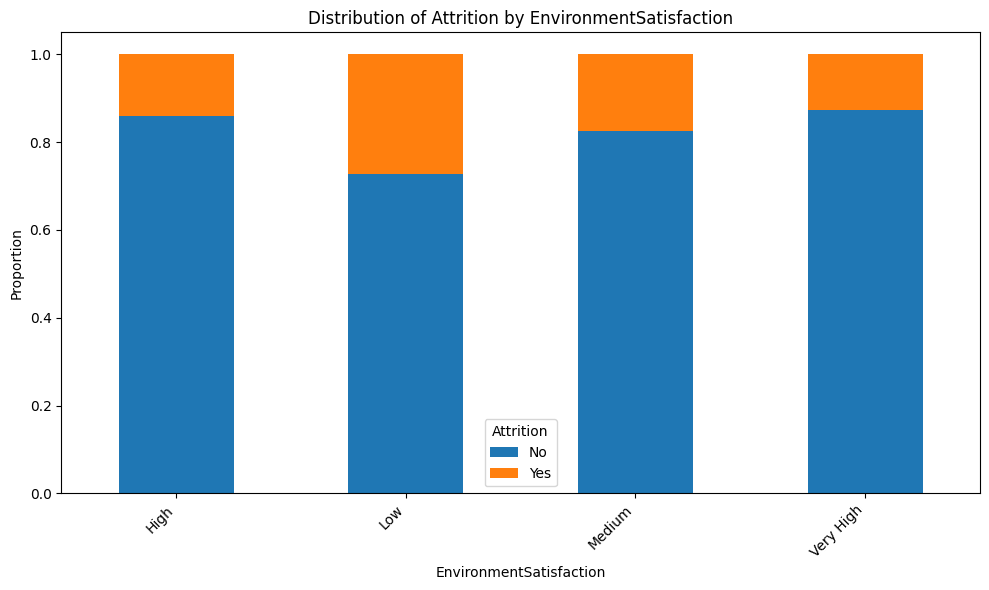

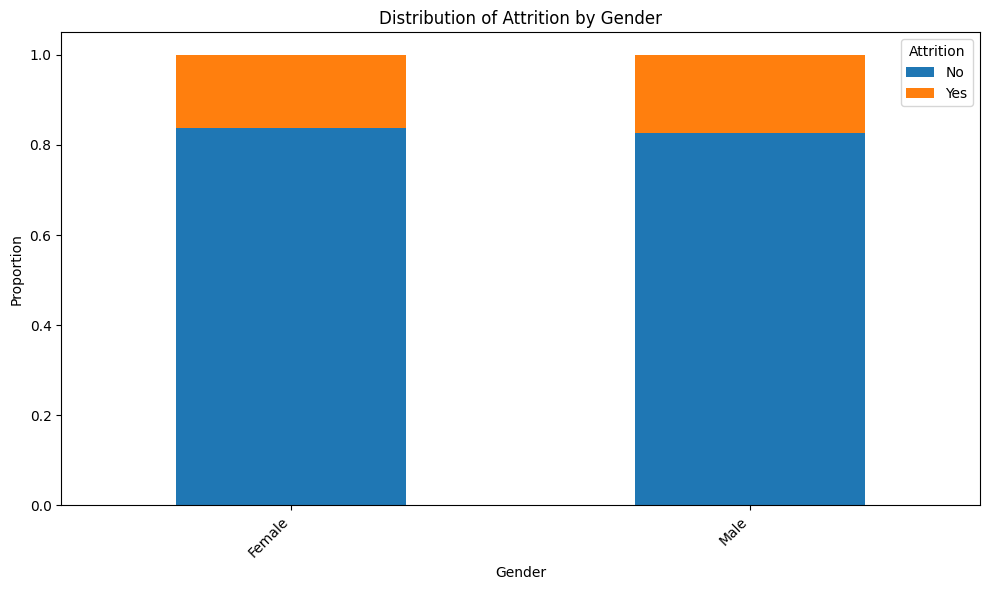

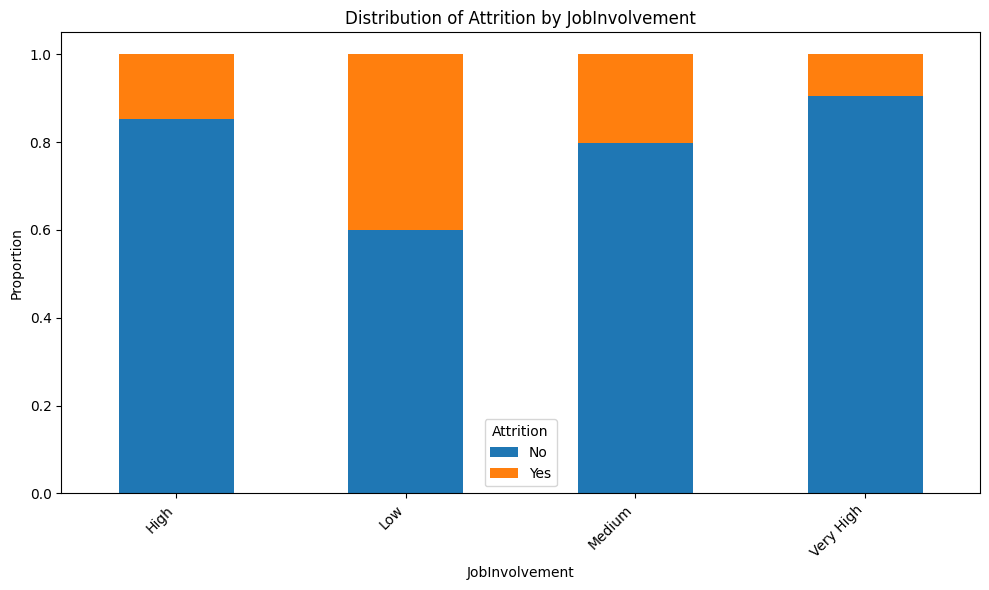

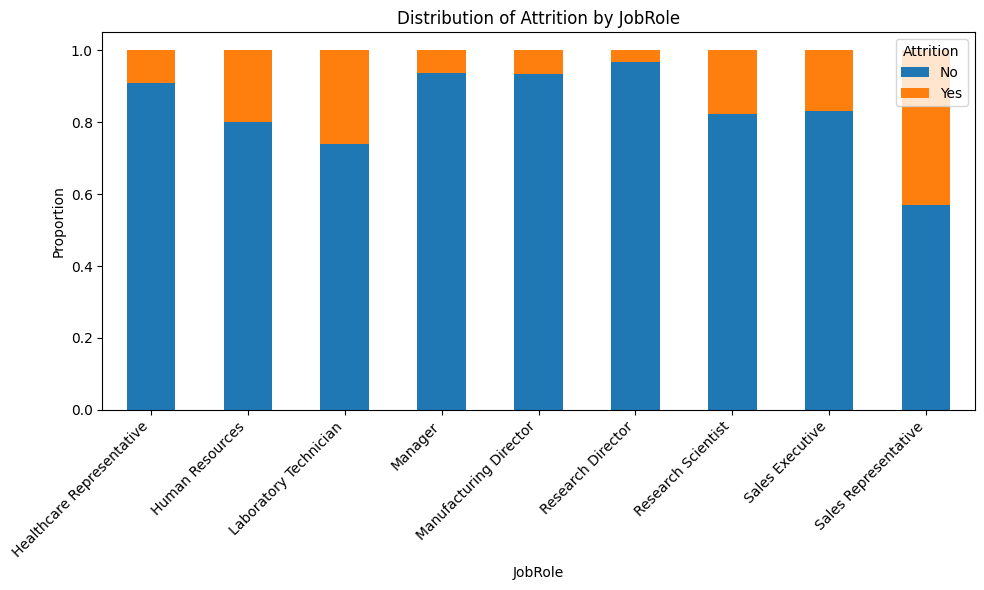

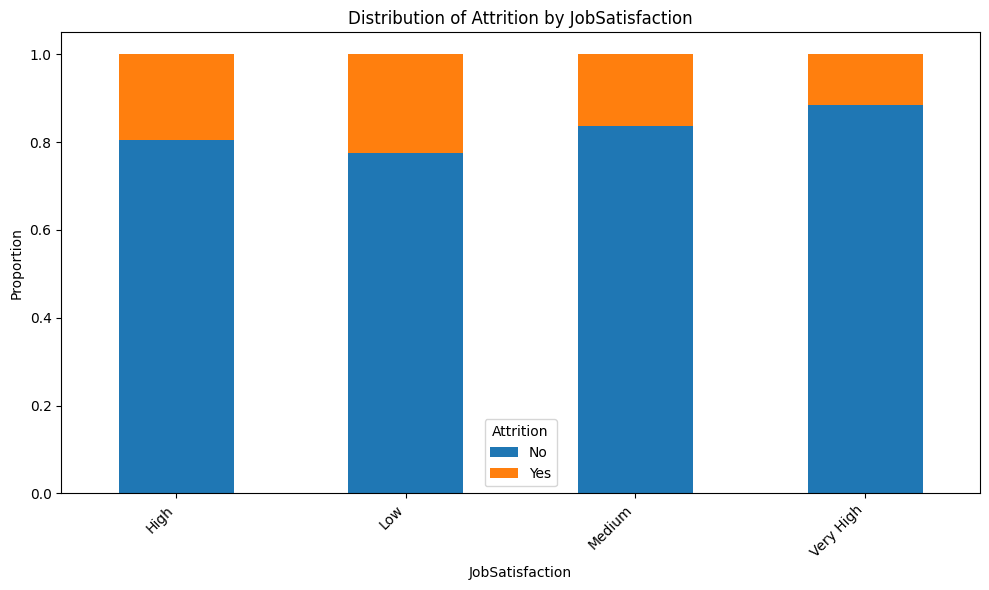

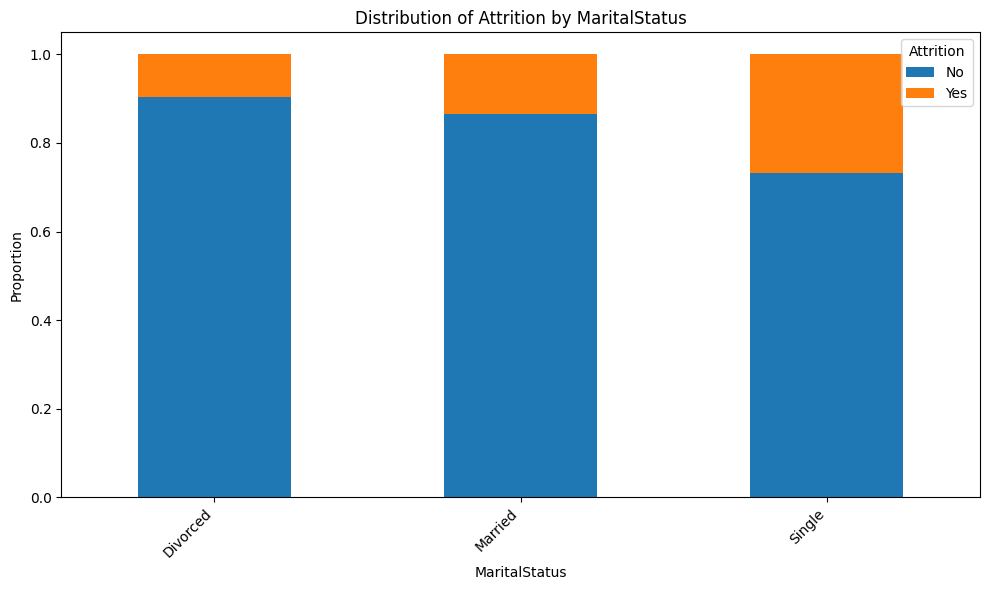

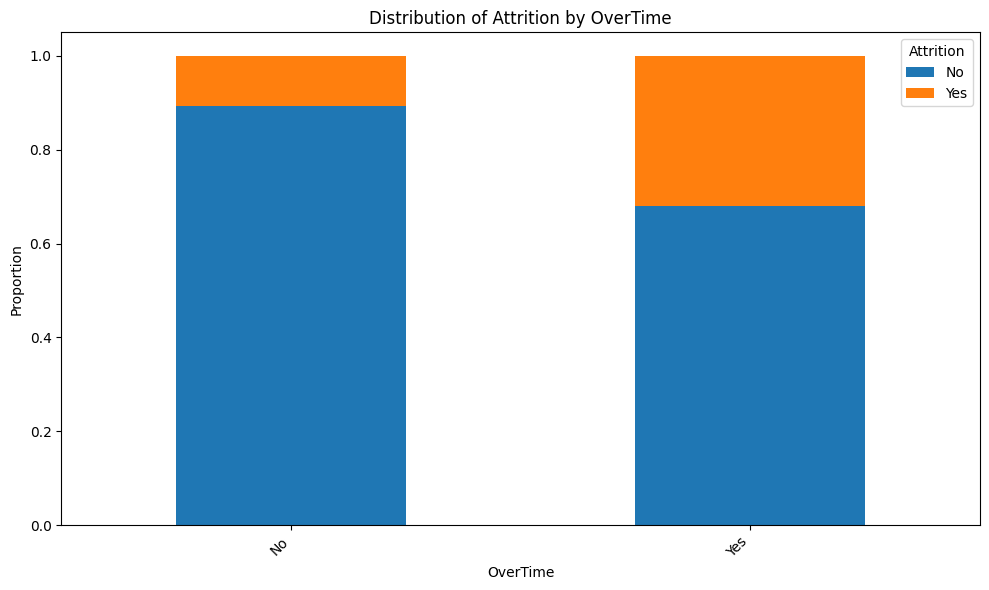

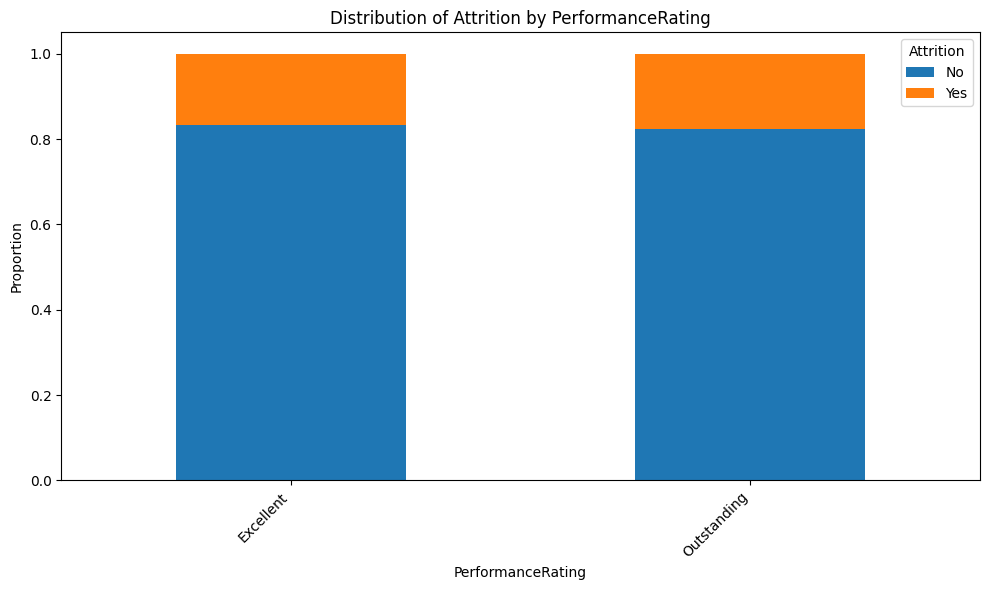

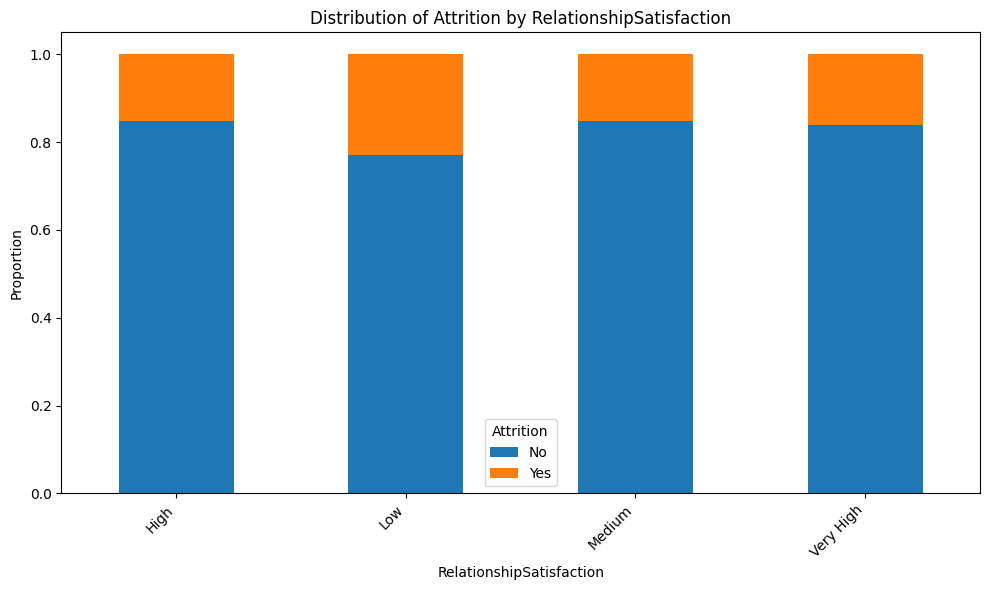

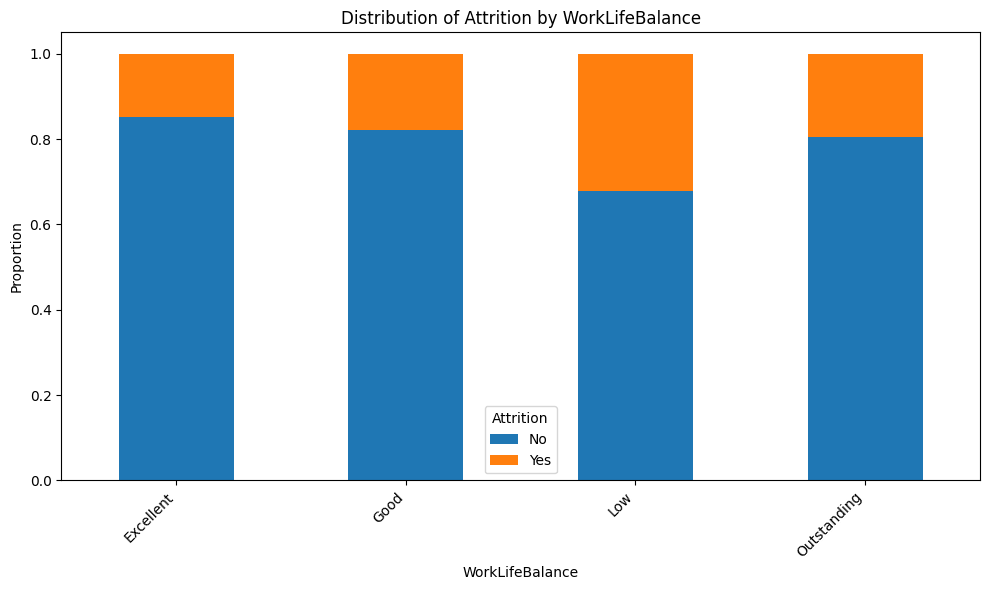

In [25]:
for feature in categorical:
  contingency_table = pd.crosstab(df[feature], df['Attrition'])
  contingency_table.div(contingency_table.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(10, 6))
  plt.title(f'Distribution of Attrition by {feature}')
  plt.ylabel('Proportion')
  plt.xlabel(feature)
  plt.legend(title='Attrition')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

Dari stacked bar chart diatas, beberapa insight yang diperoleh diantaranya:
1. `OverTime`: Karyawan yang sering lembur (OverTime = Yes) memiliki proporsi attrition yang jauh lebih tinggi.
2. `MaritalStatus`: Karyawan dengan status single lebih tentang keluar dibandingkan dengan karyawan yang sudah menikah atau bercerai.
3. `JobRole`: berapa peran seperti Sales Representative dan Laboratory Technician, memiliki attrition yang tinggi.
4. `BusinessTravel`: Karyawan yang sering melakukan peerjalanan bisnis memiliki risiko keluar lebih tinggi dibandingkan kategori lainnya.

##Menggunakan Chi-Square Test

In [26]:
categorical = [feature for feature in categorical if feature != 'Attrition']

chi_square_results = []

for feature in categorical:
    contingency_table = pd.crosstab(df[feature], df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi_square_results.append({
        'Feature': feature,
        'Chi-Square Statistic': chi2,
        'p-value': p})

chi_square_results_df = pd.DataFrame(chi_square_results)
chi_square_results_df

,Feature,Chi-Square Statistic,p-value
0,BusinessTravel,13.403348,1.228853e-03
1,Department,4.627283,9.890046e-02
2,Education,5.118766,2.753270e-01
3,EducationField,9.811529,8.075507e-02
4,EnvironmentSatisfaction,21.880082,6.908816e-05
5,Gender,0.187941,6.646360e-01
6,JobInvolvement,29.103478,2.130062e-06
7,JobRole,66.393971,2.556695e-11
8,JobSatisfaction,13.163605,4.295832e-03
9,MaritalStatus,37.621652,6.769585e-09


##Hasil Chi-Square Test

1. Fitur Signifikan terhadap Attrition (p-value < 0.05):
  - `BusinessTravel`: Karyawan dengan frekuensi perjalanan bisnis tertentu lebih cenderung mengalami attrition.
  - `JobInvolvement`: Karyawan yang terlibat lebih dalam pekerjaan mereka menunjukkan kecenderungan lebih tinggi yntuk mengalami attition.
  - `JobRole`:  Peran pekerjaan tertentu meemiliki hubungan yang sangat signifikan dengan risiko keluar karyawan.
  - `MaritalStatus`: Status pernikahan akan mempengaruhi kecenderungan karyawan untuk keluar, terutama bagi mereka yang berstatus single.
  - `OverTime`: Karyawan yang sering lembur sangat cenderung mengalami attrition.
  - `WorkLifeBalance`: Karyawan yang merasa tidak seimbang antara beban pekerjaan dan kehidupan pribadi memiliki kecenderungan yang lebih tinggi untuk keluar.
2. Fitur Tidak Signifikan (p-value >+ 0.05):
  - `Department`: Tidak ada hubungan antara departemen dan attrition.
  - `Education`:Tingkat pendidikan tidak mempengaruhi attrition secara signifikan.
  - `Gender`: Jenis kelamin tidak memiliki pengaruh terhadap kecenderungan attrition karyawan.
  - `PerformanceRating`: Penilaian kinerja tidak memiliki hubungan signifikan dengan attrition.
  - `RelationshipSatisfaction`: Kepuasan hubungan kerja tidak memiliki pengaruh yang signifikan terhadap attrition.

##Kolerasi Antar Variabel

###Kolerasi Variabel Numerik

In [27]:
correlation_matrix= df[numerical].corr()
correlation_matrix

,EmployeeId,Age,DailyRate,DistanceFromHome,HourlyRate,JobLevel,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeId,1.000000,0.037388,0.039408,-0.024201,0.000607,0.009278,0.001891,0.008678,0.022657,-0.058539,NaN,-0.020045,-0.002950,0.041028,-0.045118,-0.019571,-0.036120,-0.056947
Age,0.037388,1.000000,0.010507,-0.022753,0.005901,0.506484,0.497392,0.019262,0.303624,-0.024856,NaN,0.010683,0.690428,-0.004970,0.313454,0.210148,0.211967,0.194128
DailyRate,0.039408,0.010507,1.000000,0.027120,0.038572,0.003042,0.008371,-0.040267,0.028158,0.031179,NaN,0.044321,0.024266,-0.000817,-0.047141,-0.001487,-0.047469,-0.038338
DistanceFromHome,-0.024201,-0.022753,0.027120,1.000000,0.048494,-0.024838,-0.042127,0.027495,-0.018545,0.041835,NaN,0.048544,-0.025465,-0.005176,-0.028687,-0.005367,-0.009304,-0.005352
HourlyRate,0.000607,0.005901,0.038572,0.048494,1.000000,-0.021084,-0.014148,-0.026110,0.030150,-0.006855,NaN,0.021539,-0.017238,-0.017006,-0.022893,-0.035471,-0.049503,-0.031806
JobLevel,0.009278,0.506484,0.003042,-0.024838,-0.021084,1.000000,0.953964,0.024555,0.144195,-0.070180,NaN,0.019655,0.786925,-0.006301,0.546310,0.410976,0.361694,0.380084
MonthlyIncome,0.001891,0.497392,0.008371,-0.042127,-0.014148,0.953964,1.000000,0.016802,0.147337,-0.060257,NaN,0.012255,0.778177,0.001079,0.527952,0.386686,0.354188,0.347605
MonthlyRate,0.008678,0.019262,-0.040267,0.027495,-0.026110,0.024555,0.016802,1.000000,-0.001055,-0.015426,NaN,-0.024654,0.021230,0.016398,-0.032481,-0.017107,-0.023109,-0.024255
NumCompaniesWorked,0.022657,0.303624,0.028158,-0.018545,0.030150,0.144195,0.147337,-0.001055,1.000000,-0.002538,NaN,0.017214,0.246417,-0.047052,-0.103149,-0.077741,-0.023525,-0.096537
PercentSalaryHike,-0.058539,-0.024856,0.031179,0.041835,-0.006855,-0.070180,-0.060257,-0.015426,-0.002538,1.000000,NaN,-0.015467,-0.053250,-0.014550,-0.053862,-0.018894,-0.036548,-0.029423


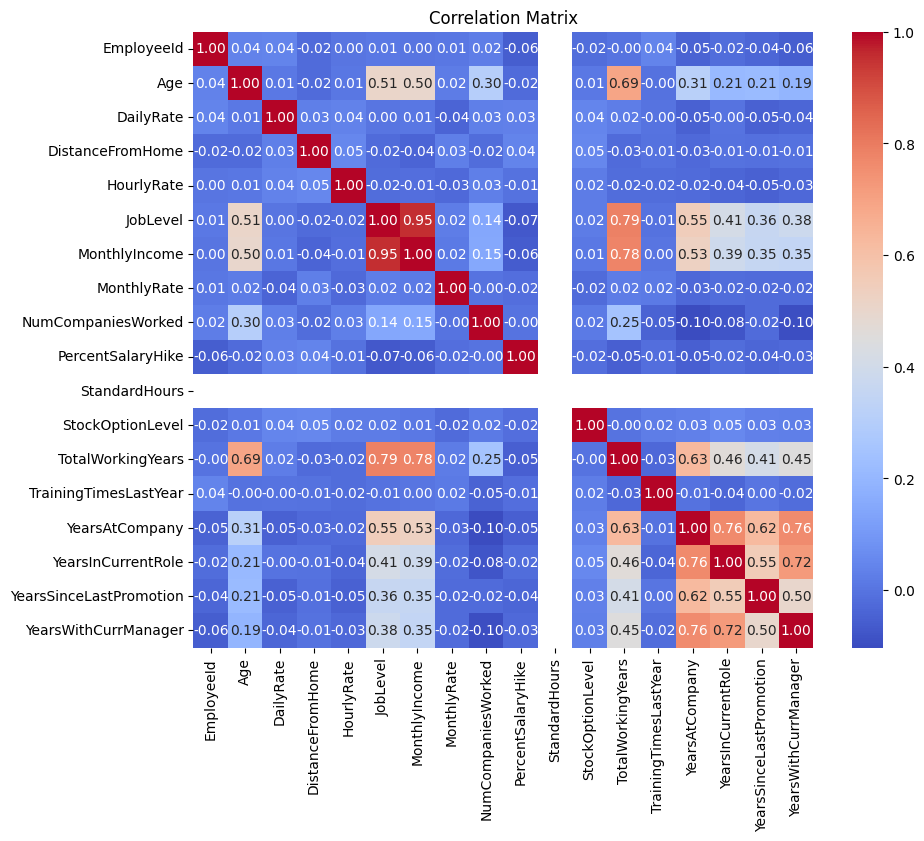

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Fitur-fitur yang sudah divisualisasikan menggunakan heatmap. Diperoleh insight bahwa fitur-fitur seperti `MonthlyIncome`, `TotalYearsWorking`, dan `YearsAtCompany` memiliki korelasi positif yang kuat (0.77)

##Korelasi Variabel Kategorik

In [29]:
# Cramer's V for Categorical-Categorical Correlation
def cramers_v(confusion_matrix):
  chi2 = chi2_contingency(confusion_matrix)[0]
  n = confusion_matrix.sum()
  return np.sqrt(chi2 / (n*(min(confusion_matrix.shape)-1)))

cramers_v_results = []
for i, feature1 in enumerate(categorical):
  for feature2 in categorical[i+1:]:
    confusion_matrix = pd.crosstab(df[feature1], df[feature2])
    cramers_v_value = cramers_v(confusion_matrix)
    cramers_v_results.append({
        'Feature1': feature1,
        'Feature2': feature2,
        'Cramers V': cramers_v_value})

In [30]:
cramers_v_results_df = pd.DataFrame(cramers_v_results)
cramers_v_results_df

,Feature1,Feature2,Cramers V
0,BusinessTravel,Department,Department Human Resources 0.212507 ...
1,BusinessTravel,Education,Education Bachelor 0.092793 Below Coll...
2,BusinessTravel,EducationField,EducationField Human Resources 0.530496 Li...
3,BusinessTravel,EnvironmentSatisfaction,EnvironmentSatisfaction High 0.078165 ...
4,BusinessTravel,Gender,Gender Female 0.108835 Male 0.091476 d...
...,...,...,...
86,OverTime,RelationshipSatisfaction,RelationshipSatisfaction High 0.090434...
87,OverTime,WorkLifeBalance,WorkLifeBalance Excellent 0.079281 Good ...
88,PerformanceRating,RelationshipSatisfaction,RelationshipSatisfaction High 0.054364...
89,PerformanceRating,WorkLifeBalance,WorkLifeBalance Excellent 0.102392 Good ...


##Hasil Cramer's V (Hubungan Variabel Kategorikal)

1. Hubungan Tinggi (Cramer's V > 0.3):
- `BusinessTravel` dan `JobRole`: Ada hubungan moderat antara frekuensi perjalanan bisnis dengan jenis pekerjaan.
- `Gender` dan `JobRole`: Ada hubungan moderat antara gender dan jenis pekerjaan.
2. Hubungan Rendah (Cramer's C < 0.3):
- Sebagian besar hubungan antar variabel kategorikal bersifat lemah, seperti hubungan antara `BusinessTravel` dan `MaritalStatus`.

## Data Preprocessing


Karena ada beberapa fitur yang tidak berkontribusi atau memengaruhi tingkat pengunduran diri dalam dataset ini, seperti EmployeeID, fitur-fitur ini perlu di hapus.

In [31]:
df = df.drop(['EmployeeId'], axis=1)

## Label Encoding

Pada bagian ini akan dilakukan:
- Memisahkan fitur numerik dan kategorikal dalam dataset.
- Mengubah fitur kategorikal agar dapat menjadi format numerik menggunakan Label Encoding agar bisa digunakan dalam Machine Learning.

In [32]:
numerical, categorical = [], []

for feature in df.columns:
  if not df[feature].dtype == 'object':
    numerical.append(feature)
  else:
    categorical.append(feature)

le = LabelEncoder()
df[categorical] = df[categorical].apply(le.fit_transform)

##Data Normalization

Bagian berikut digunakan untuk melakukan normalisasi atau penskalaan pada fitur numerik dalam dataset menggunakan teknik Min-Max Scaling. Penskalaan ini penting untuk memastikan bahwa fitur numerik memiliki skala yang seragam.

In [33]:
scaler = MinMaxScaler()
df[numerical] = scaler.fit_transform(df[numerical])

In [34]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,0.452381,1,2,0.743737,1,0.357143,2,3,1,0,...,1,0.0,0.000000,0.375,0.333333,2,0.025,0.000000,0.000000,0.000000
2,0.785714,1,2,0.874016,1,0.107143,4,1,1,1,...,0,0.0,1.000000,0.450,0.333333,3,0.250,0.000000,0.133333,0.411765
3,0.571429,0,1,0.324266,2,0.892857,0,2,0,0,...,3,0.0,0.333333,0.575,0.333333,3,0.500,0.222222,0.266667,0.470588
6,0.523810,0,2,0.731568,2,0.000000,2,3,2,1,...,0,0.0,1.000000,0.150,0.333333,1,0.100,0.166667,0.000000,0.117647
7,0.880952,1,2,0.445956,1,0.035714,0,3,3,1,...,3,0.0,0.333333,0.600,0.333333,0,0.125,0.111111,0.066667,0.235294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,0.238095,1,0,0.904796,1,0.821429,2,5,2,1,...,1,0.0,0.000000,0.250,0.333333,1,0.250,0.388889,0.066667,0.529412
1465,0.476190,0,2,0.047244,1,0.000000,0,1,0,0,...,3,0.0,0.000000,0.250,0.666667,3,0.025,0.000000,0.000000,0.000000
1467,0.238095,1,2,0.989979,1,0.392857,1,1,0,0,...,3,0.0,0.000000,0.025,0.666667,1,0.025,0.055556,0.000000,0.000000
1468,0.523810,0,0,0.254832,1,0.535714,2,1,0,1,...,2,0.0,0.333333,0.150,0.000000,0,0.100,0.111111,0.000000,0.000000


Melakukan feature selection dengan RFE

In [35]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [36]:
from sklearn.feature_selection import RFE
rfe_selector = RFE(estimator=LogisticRegression(), n_features_to_select=10, step=1)
rfe_selector.fit(x, y)

RFE(estimator=LogisticRegression(), n_features_to_select=10)

In [37]:
# Select top features
selected_features = x.columns[rfe_selector.support_]

# Create a new DataFrame with only the selected features
X_selected = df[selected_features]

Split Data

In [38]:
# Split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (846, 10)
X_test shape: (212, 10)
y_train shape: (846,)
y_test shape: (212,)


Melakukan SMOTE untuk menangani imbalance data

In [39]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## Modeling

Tahapan ini akan dilakukan pemodelan menggunakan berbagai classifier

##Logistic Regression

In [40]:
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)
logistic_y_pred = logistic_model.predict(X_test)

##Random Forest

In [41]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

##XGBoost Classifier

In [42]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)

##SVM

In [43]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_y_pred = svm_model.predict(X_test)

## Evaluation

In [44]:
# Metrics for Logistic Regression
logistic_accuracy = accuracy_score(y_test, logistic_y_pred)
logistic_precision = precision_score(y_test, logistic_y_pred)
logistic_recall = recall_score(y_test, logistic_y_pred)
logistic_f1 = f1_score(y_test, logistic_y_pred)


In [45]:
# Metric for Random Forest
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

In [46]:
# Metric for XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)

In [47]:
# Metric for SVM
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred)
svm_recall = recall_score(y_test, svm_y_pred)
svm_f1 = f1_score(y_test, svm_y_pred)

In [48]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [logistic_accuracy, rf_accuracy, xgb_accuracy, svm_accuracy],
    'Precision': [logistic_precision, rf_precision, xgb_precision, svm_precision],
    'Recall': [logistic_recall, rf_recall, xgb_recall, svm_recall],
    'F1 Score': [logistic_f1, rf_f1, xgb_f1, svm_f1]
})

In [49]:
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844340,0.800000,0.205128,0.326531
1,Random Forest,0.839623,0.727273,0.205128,0.320000
2,XGBoost,0.801887,0.428571,0.230769,0.300000
3,SVM,0.844340,1.000000,0.153846,0.266667


In [50]:
# Detailed Clasification Reports
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_y_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_y_pred))

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       173
           1       0.80      0.21      0.33        39

    accuracy                           0.84       212
   macro avg       0.82      0.60      0.62       212
weighted avg       0.84      0.84      0.80       212


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       173
           1       0.73      0.21      0.32        39

    accuracy                           0.84       212
   macro avg       0.79      0.59      0.61       212
weighted avg       0.82      0.84      0.80       212


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       173
           1       0.43      0.23      0.30        39

    accuracy                           0.80       212
   macro avg   

Hasil dari pemodelan tersebut, menunjukkan bahwa model Logistic Regression sebagai model terbaik.

#Analisis Future Importance Macine Learning

In [51]:
# SHAP values untuk model Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

In [52]:
# Mengambil feature importance dari model Random Forest
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})

In [53]:
# Membuat DataFrame untuk feature importance
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})

# Mengurutkan DataFrame berdasarkan importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

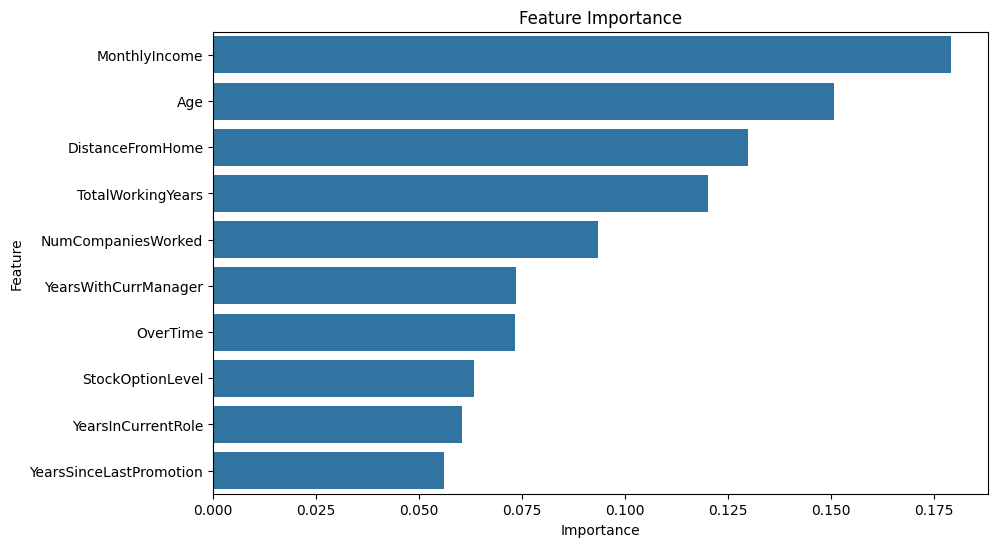

In [54]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Dari analisisi feature importance tersebut, terlihat bahwa 5 variabel yang paling berpengaruh adalah ...

#Conclusion

Proyek ini bertujuan untuk memahami faktor-faktor yang mempengaruhi tingkat attrition (keluar) karyawan dari perusahaan Jaya Jaya Maju dan membangun model prediktif untuk mengidentifikasi karyawan dengan risiko keluar tinggi. Berikut ini adalah temuan-temuan utama dan insight yang diperoleh:

#1. Faktor-faktor Penyebab Attrition
Berdasarkan analisis data dan model prediktif, berikut adalah faktor utama yang mempengaruhi attrition:
1. `OverTime`
- Karyawan yang sering lembur (OverTime = Yes) memiliki risiko keluar yang jauh lebih tinggi dibandingkan dengan yang tidak lembur.
- Fitur ini adalah prediktor terkuat dalam model prediktif.
2. `MonthlyIncome`
- Pendapatan yang lebih rendah meningkatkan risiko keluar karyawan.
- Fitur ini mencerminkan pentingnya kepuasan finansial dalam retensi karyawan.
3. `YearsAtCompany` dan `TotalWorkingYears`
- Masa kerja pendek baik di perusahaan maupun secara total adalah indikator risiko tinggi.
4. Fitur pendukung lain
- Fitur seperti `DistanceFromHome` dan `Age` memiliki kontribusi kecil, tetapi tetap relevan dalam memahami pola attrition.

#2. Model Prediktif Terbaik
Model terbaik yang digunakan dalam proyek ini adalah Random Forest dengan metrik performa sebagai berikut:
- Accuracy: 84%
- Precision: 85%
- Recall: 99%
- F1-Score: 91%
  
#3. Feature Importance
Dari analisis feature importance menggunakan model Random Forest, didaparkan bahwa:
- `TotalWorkingYears` adalah fitur dengan kontribusi terbesar terhadap prediksi.
- `YearsAtCompany` dan `Age` juga memiliki peran penting.

##Jawaban terhadap Pertanyaan Bisnis
1. Apa faktor utama yang memengaruhi attrition?
- Faktor utama adalah OverTime, MonthlyIncome, dan YearsAtCompany.
2. Bagaimana tingkat kepuasan karyawan memengaruhi attrition?
- Fitur seperti JobSatisfaction tidak signifikan dalam model prediktif, tetapi tetap relevan secara deskriptif.
3. Apa pola perilaku karyawan dengan risiko keluar tinggi?
- Karyawan yang lembur berlebihan, memiliki pendapatan rendah, dan masa kerja pendek cenderung memiliki risiko tinggi.
4. Apakah kita memiliki alat bantu untuk memantau attrition?
- Model prediktif dan visualisasi hasil dapat digunakan untuk membangun dashboard interaktif untuk monitoring risiko.

## Karakteristik Umum Karyawan yang Melakukan Attrition
Berdasarkan analisis data, berikut adalah karakteristik umum karyawan yang melakukan attrition:

1. Demografis:
- Usia: Rata-rata usia karyawan yang keluar adalah 30-an tahun.
- Jenis Kelamin: Mayoritas adalah pria (Male).
- Status Pernikahan: Sebagian besar karyawan yang keluar adalah Single, diikuti oleh Married.
2. Pekerjaan dan Departemen:
- Peran Kerja: Posisi yang paling sering melakukan attrition adalah Laboratory Technician.
- Departemen: Departemen Research & Development memiliki tingkat attrition tertinggi.
3. Faktor Finansial dan Beban Kerja:
- Pendapatan: Rata-rata pendapatan bulanan karyawan yang keluar adalah 4,872.
- Lembur (OverTime): Sebagian besar karyawan yang keluar bekerja lembur secara signifikan.
4. Kepuasan dan Keseimbangan:
- Kepuasan Kerja: Rata-rata tingkat kepuasan kerja adalah 2.5 (Medium).
- Keseimbangan Kerja-Hidup: Rata-rata berada di tingkat 2.67 (Moderate).
5. Masa Kerja:
- Masa Kerja di Perusahaan: Rata-rata masa kerja adalah 5 tahun, dengan beberapa karyawan memiliki masa kerja sangat panjang hingga 40 tahun.

#Rekomendasi Action Items untuk Perusahaan
1. Kurangi Lembur Berlebihan:
Berikan program kerja fleksibel untuk meningkatkan keseimbangan kerja-hidup.
2. Kaji Skala Gaji:
Sesuaikan gaji karyawan agar kompetitif di pasar dan berikan insentif tambahan.
3. Perkuat Retensi Karyawan Baru:
Implementasikan program onboarding dan mentoring untuk karyawan dengan masa kerja pendek.
4. Mengidentifikasi karyawan dengan YearsAtCompany dan TotalWorkingYears yang pendek, lalu memberikan perhatian khusus terhadap pengembangan karier dan kepuasan mereka.
5. Menciptakan lingkungan kerja yang lebih inklusif dan mendukung bagi karyawan dari berbagai kelompok usia.
6. Gunakan Model Prediktif:
Integrasikan model Random Forest untuk memonitor risiko secara real-time melalui dashboard HR.

#Model Export


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
joblib.dump(logistic_model, '/content/drive/MyDrive/logistic_model.joblib')
joblib.dump(rf_model, '/content/drive/MyDrive/rf_model.joblib')
joblib.dump(xgb_model, '/content/drive/MyDrive/xgb_model.joblib')
joblib.dump(svm_model, '/content/drive/MyDrive/svm_model.joblib')


['/content/drive/MyDrive/svm_model.joblib']